# Punto 2 – Inteligencia de clientes

## 2.1 Segmentación de clientes

**Pregunta:** Diseña y ejecuta una segmentación de clientes que permita a nuestro equipo de marketing distinguir claramente a los "clientes fieles" de los compradores esporádicos o en riesgo de abandono.

**El reto de este dataset:** de 94.990 clientes reales, el 97% compró una sola vez. La **Frecuencia casi no discrimina**, así que la segmentación no puede depender de ella: el peso lo llevan la **Recencia** (¿sigue activo?) y el **Monetario** (¿cuánto vale?), con umbrales calculados de los datos.

**Decisiones analíticas** (registradas en `SUPUESTOS.md`):

| Decisión | Criterio | Por qué |
|---|---|---|
| Pedidos incluidos | Todos menos `canceled` y `unavailable` | Un pedido cancelado no es venta ni historial de compra utilizable |
| Cliente | `customer_unique_id` | `customer_id` cambia en cada pedido; el cliente real es el único |
| Monto | `payment_value` agregado **por pedido** | Es lo que el cliente realmente pagó (incluye flete). Nunca se une `order_payments` con `order_items`: duplicaría montos |
| Ventana | Se recortan los meses incompletos del final (< 10% del promedio mensual) | Si no, la Recencia se mide contra una fecha sin actividad real |
| Fecha de referencia | Día siguiente a la última compra de la ventana | Recencia = 0 para el cliente más reciente, sin recencias negativas |
| Umbral de riesgo | Percentil 75 de los días entre compras **reales** | Si 3 de cada 4 recompras ocurren dentro de X días, pasado X el cliente salió del ciclo |
| Recompra real | Se excluyen los intervalos de 0 días | El 30% de los "segundos pedidos" son del mismo día: es un carrito partido entre vendedores, no una recompra |
| Alto valor | Percentil 90 del gasto total | El corte lo pone la distribución del negocio, no una cifra a dedo |


### Preparación

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RUTA_PROYECTO = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(RUTA_PROYECTO))

from src.data_loader import (
    ESTADOS_SENSIBILIDAD,
    RUTA_PROCESSED,
    cargar_datos,
    construir_items_enriquecidos,
)
from src.features import construir_historial_compras
from src.segmentation import (
    ACCIONES_MARKETING,
    ORDEN_SEGMENTOS,
    PERCENTIL_PERDIDO,
    PERCENTIL_RIESGO,
    PERCENTIL_VIP,
    construir_base_pedidos,
    construir_clientes,
    evaluar_k,
    perfil_segmentos,
    preparar_matriz_kmeans,
    segmentar_kmeans,
    segmentar_reglas,
    umbrales_recencia,
)
from src.utils import (
    COLOR_BARRA,
    COLOR_DESTACADO,
    COLOR_TEXTO,
    RUTA_FIGURAS,
    formato_moneda,
    guardar_tabla,
    imprimir_checklist,
)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

In [2]:
dfs = cargar_datos()
print({nombre: df.shape for nombre, df in dfs.items()})

{'clientes': (99441, 5), 'geolocalizacion': (1000163, 5), 'items_pedido': (112650, 7), 'pagos': (103886, 5), 'resenas': (99224, 7), 'pedidos': (99441, 8), 'productos': (32951, 9), 'vendedores': (3095, 4), 'traduccion_categorias': (71, 2)}


### Paso 1 – Base de pedidos válidos, ventana de análisis y fecha de referencia

Un pedido por fila, con el cliente real, el monto pagado, el medio de pago y la UF. Aquí se recortan los meses incompletos del final de la serie.

In [3]:
base, info = construir_base_pedidos(dfs)
items = construir_items_enriquecidos(dfs, estados_validos=ESTADOS_SENSIBILIDAD, verbose=False)
fecha_referencia = info["fecha_referencia"]
print(f"\nÍtems de pedidos válidos: {len(items):,}")

Meses incompletos recortados : ['2018-09'] (< 409 pedidos)
Pedidos en la ventana        : 98,206
Última compra                : 2018-08-29 15:00:37
Fecha de referencia          : 2018-08-30


Merge con clientes conserva filas : True
Nulos en customer_unique_id       : 0
Pedidos sin registro de pago      : 1 (monto tomado de los ítems)
Clientes reales en la ventana     : 94,990



Ítems de pedidos válidos: 112,101


In [4]:
# La serie mensual muestra por qué hay que recortar: septiembre de 2018 tiene 1 pedido
serie_mensual = (
    dfs["pedidos"]
    .groupby(dfs["pedidos"]["order_purchase_timestamp"].dt.to_period("M"))
    .size()
)
print(serie_mensual.tail(5).to_string())
print(f"\nPromedio mensual: {serie_mensual.mean():,.0f} pedidos")

order_purchase_timestamp
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M

Promedio mensual: 3,978 pedidos


### Paso 2 – Umbral de "riesgo de abandono" calculado con los datos

No se fija un umbral a dedo: se miden los días que pasan entre las compras de los clientes que sí volvieron. El percentil 75 de esos intervalos es el punto en el que un cliente "ya debería haber vuelto".

Antes de medir hay que limpiar un artefacto: **el 30% de los segundos pedidos ocurre el mismo día** que el primero. Eso no es un cliente que vuelve, es un mismo carrito que Olist parte en varios pedidos porque los productos vienen de vendedores distintos. Si se cuentan, el ciclo de recompra se ve artificialmente corto.

In [5]:
umbrales = umbrales_recencia(base)
UMBRAL_RIESGO = umbrales["umbral_riesgo"]
UMBRAL_PERDIDO = umbrales["umbral_perdido"]

Intervalos entre compras       : 3,216
De los cuales el mismo día     : 965 (30.0%) -> se excluyen
Mediana de días entre compras  : 71
Umbral de riesgo (p75)       : 171 días
Umbral de perdido (p90)      : 281 días


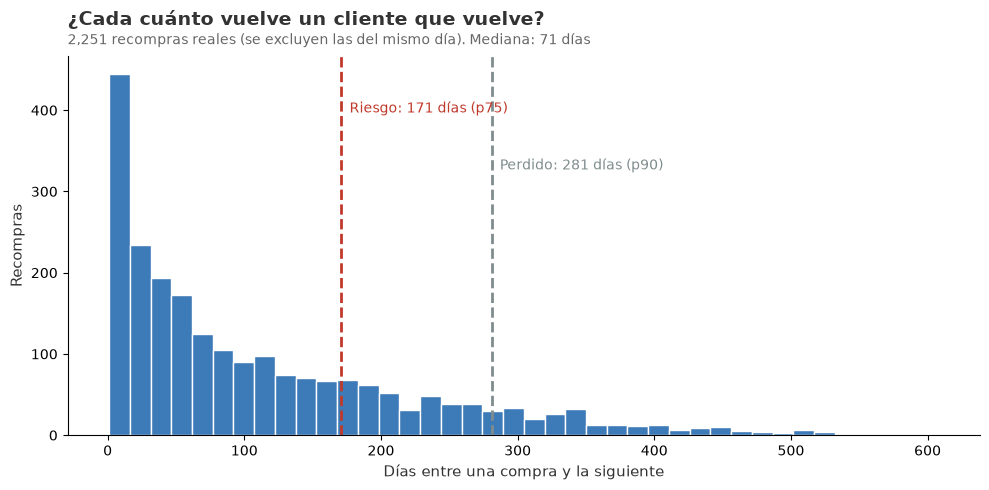

In [6]:
intervalos = umbrales["serie_intervalos"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(intervalos, bins=40, color=COLOR_BARRA, edgecolor="white")
ax.axvline(UMBRAL_RIESGO, color="#c0392b", linestyle="--", linewidth=2)
ax.axvline(UMBRAL_PERDIDO, color="#7f8c8d", linestyle="--", linewidth=2)
ax.text(UMBRAL_RIESGO + 6, ax.get_ylim()[1] * 0.85, f"Riesgo: {UMBRAL_RIESGO} días (p75)", color="#c0392b", fontsize=10)
ax.text(UMBRAL_PERDIDO + 6, ax.get_ylim()[1] * 0.70, f"Perdido: {UMBRAL_PERDIDO} días (p90)", color="#7f8c8d", fontsize=10)
ax.set_xlabel("Días entre una compra y la siguiente", fontsize=11, color=COLOR_TEXTO)
ax.set_ylabel("Recompras", fontsize=11, color=COLOR_TEXTO)
for lado in ("top", "right"):
    ax.spines[lado].set_visible(False)
ax.set_title("¿Cada cuánto vuelve un cliente que vuelve?", fontsize=14, fontweight="bold", loc="left", pad=22, color=COLOR_TEXTO)
ax.text(0, 1.03, f"{len(intervalos):,} recompras reales (se excluyen las del mismo día). Mediana: {intervalos.median():.0f} días",
        transform=ax.transAxes, fontsize=10, color="#666666")
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / "2_1_dias_entre_compras.png", dpi=150, bbox_inches="tight")
plt.show()

### Paso 3 – Tabla de clientes: RFM + comportamiento + dolor del 1.2

Una fila por `customer_unique_id`. Además del RFM clásico se traen las variables que marketing necesita para accionar y el resultado del punto 1.2 (`tuvo_mala_experiencia` y `motivo_principal`), que es lo que conecta esta segmentación con el agente del punto 3.2.

In [7]:
clientes_dolor = pd.read_parquet(RUTA_PROCESSED / "clientes_dolor.parquet")
clientes = construir_clientes(base, items, clientes_dolor, fecha_referencia)
print(f"\nColumnas: {list(clientes.columns)}")
clientes[["frecuencia", "dias_compra", "recencia", "gasto_total", "ticket_promedio", "categorias_distintas", "score_promedio"]].describe().round(1)

Clientes en la tabla        : 94,990
Recencias negativas         : 0
Gasto total                 : R$ 15,739,114
Clientes sin score de reseña: 685

Columnas: ['customer_unique_id', 'frecuencia', 'dias_compra', 'gasto_total', 'ticket_promedio', 'primera_compra', 'ultima_compra', 'cuotas_promedio', 'estado', 'ciudad', 'recencia', 'antiguedad', 'metodo_pago', 'categorias_distintas', 'categoria_favorita', 'score_promedio', 'tuvo_mala_experiencia', 'motivo_principal', 'max_retraso_dias']


,frecuencia,dias_compra,recencia,gasto_total,ticket_promedio,categorias_distintas,score_promedio
count,94990.0,94990.0,94990.0,94990.0,94990.0,94990.0,94305.0
mean,1.0,1.0,238.3,165.7,160.8,1.0,4.1
std,0.2,0.2,153.0,226.7,219.9,0.2,1.3
min,1.0,1.0,0.0,9.6,9.6,0.0,1.0
25%,1.0,1.0,114.0,63.1,62.4,1.0,4.0
50%,1.0,1.0,219.0,107.9,105.7,1.0,5.0
75%,1.0,1.0,347.0,182.9,177.0,1.0,5.0
max,16.0,16.0,724.0,13664.1,13664.1,5.0,5.0


### Paso 4 – Enfoque A: reglas de negocio RFM (interpretables)

Cinco segmentos mutuamente excluyentes, evaluados en este **orden de prioridad**:

1. **Fieles** – volvieron otro día (`dias_compra` ≥ 2) y siguen dentro del ciclo (recencia ≤ 171 días).
2. **VIP / Alto valor** – gasto en el top 10% (≥ R$ 319), con cualquier frecuencia.
3. **Esporádicos recientes** – una sola compra, todavía dentro del ciclo de recompra.
4. **En riesgo de abandono** – pasaron el umbral de 171 días pero no el de 281.
5. **Perdidos / Inactivos** – más de 281 días sin comprar.

El orden no es arbitrario: un cliente fiel de gasto medio le interesa a marketing **como fiel** (hay hábito que cultivar), y un comprador único de gasto alto le interesa **como VIP** (hay valor que retener). Como hay fieles y perdidos que también son de alto valor, el gasto top se conserva además como bandera transversal `alto_valor`.

In [8]:
clientes = segmentar_reglas(clientes, UMBRAL_RIESGO, UMBRAL_PERDIDO)
perfil_reglas = perfil_segmentos(clientes, "segmento")
perfil_reglas

Corte de alto valor (p90 de gasto): R$ 318.97
Clientes sin segmento                : 0


,segmento,clientes,pct_clientes,ingresos,pct_ingresos,recencia_mediana,frecuencia_media,gasto_mediano,ticket_mediano,score_promedio,pct_mala_experiencia,top_categorias
0,Fieles,1060,1.12,345945.67,2.20,84.5,2.17,239.92,114.42,4.30,18.87,"Cama, mesa y baño, Deporte y ocio, Belleza y s..."
1,VIP / Alto valor,9141,9.62,5809864.87,36.91,225.0,1.07,472.41,458.58,3.96,18.82,"Belleza y salud, Relojes y regalos, Informátic..."
2,Esporádicos recientes,32248,33.95,3659645.42,23.25,88.0,1.00,98.29,98.04,4.21,11.84,"Belleza y salud, Cama, mesa y baño, Deporte y ..."
3,En riesgo de abandono,22727,23.93,2577721.97,16.38,226.0,1.03,97.51,95.44,3.94,17.85,"Cama, mesa y baño, Deporte y ocio, Informática..."
4,Perdidos / Inactivos,29814,31.39,3345936.08,21.26,402.0,1.02,95.21,93.30,4.18,11.96,"Cama, mesa y baño, Deporte y ocio, Muebles y d..."


In [9]:
# Sub-grupos accionables dentro de los segmentos grandes
clientes["subsegmento"].value_counts().to_frame("clientes")

,clientes
subsegmento,
Esporádicos recientes,32248
Perdidos / Inactivos,26247
En riesgo de abandono,18397
Una compra con mala experiencia,3987
Perdido con mala experiencia,3567
VIP dormido,3415
VIP activo,3400
VIP en riesgo,2326
Fieles,1060


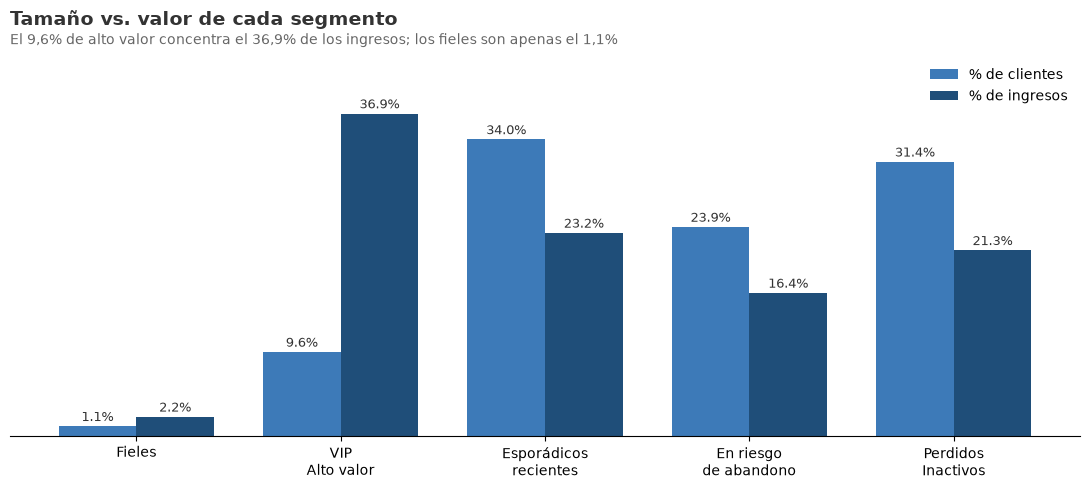

In [10]:
datos = perfil_reglas.set_index("segmento").loc[ORDEN_SEGMENTOS]
x = np.arange(len(datos))
ancho = 0.38

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - ancho / 2, datos["pct_clientes"], ancho, color=COLOR_BARRA, label="% de clientes")
b2 = ax.bar(x + ancho / 2, datos["pct_ingresos"], ancho, color=COLOR_DESTACADO, label="% de ingresos")
for barras in (b1, b2):
    for barra in barras:
        ax.text(barra.get_x() + barra.get_width() / 2, barra.get_height() + 0.6,
                f"{barra.get_height():.1f}%", ha="center", fontsize=9, color=COLOR_TEXTO)

ax.set_xticks(x)
ax.set_xticklabels([s.replace(" / ", "\n").replace(" de abandono", "\nde abandono").replace("Esporádicos ", "Esporádicos\n") for s in datos.index], fontsize=10)
ax.set_yticks([])
ax.set_ylim(0, max(datos["pct_ingresos"].max(), datos["pct_clientes"].max()) * 1.18)
for lado in ("top", "right", "left"):
    ax.spines[lado].set_visible(False)
ax.legend(frameon=False, fontsize=10)
ax.set_title("Tamaño vs. valor de cada segmento", fontsize=14, fontweight="bold", loc="left", pad=22, color=COLOR_TEXTO)
ax.text(0, 1.03, "El 9,6% de alto valor concentra el 36,9% de los ingresos; los fieles son apenas el 1,1%",
        transform=ax.transAxes, fontsize=10, color="#666666")
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / "2_1_segmentos_tamano_ingresos.png", dpi=150, bbox_inches="tight")
plt.show()

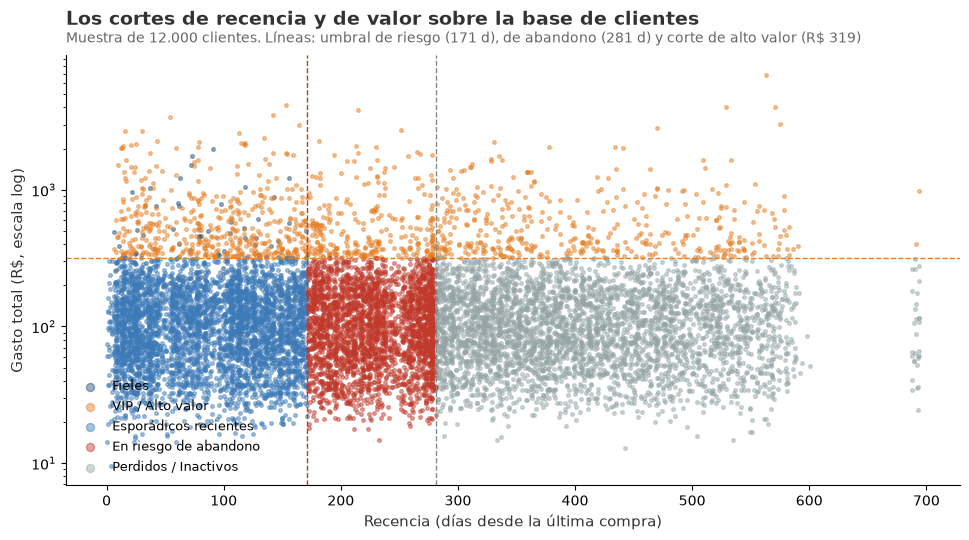

In [11]:
# Dónde queda cada segmento en el plano recencia-gasto (muestra para que el gráfico sea legible)
muestra = clientes.sample(n=12_000, random_state=42)
colores = {
    "Fieles": "#1f4e79",
    "VIP / Alto valor": "#e67e22",
    "Esporádicos recientes": "#3d7ab8",
    "En riesgo de abandono": "#c0392b",
    "Perdidos / Inactivos": "#95a5a6",
}

fig, ax = plt.subplots(figsize=(10, 5.5))
for segmento in ORDEN_SEGMENTOS:
    sub = muestra[muestra["segmento"] == segmento]
    ax.scatter(sub["recencia"], sub["gasto_total"], s=7, alpha=0.45, color=colores[segmento], label=segmento)

ax.axvline(UMBRAL_RIESGO, color="#c0392b", linestyle="--", linewidth=1)
ax.axvline(UMBRAL_PERDIDO, color="#7f8c8d", linestyle="--", linewidth=1)
ax.axhline(clientes["gasto_total"].quantile(PERCENTIL_VIP), color="#e67e22", linestyle="--", linewidth=1)
ax.set_yscale("log")
ax.set_xlabel("Recencia (días desde la última compra)", fontsize=11, color=COLOR_TEXTO)
ax.set_ylabel("Gasto total (R$, escala log)", fontsize=11, color=COLOR_TEXTO)
for lado in ("top", "right"):
    ax.spines[lado].set_visible(False)
ax.legend(frameon=False, fontsize=9, markerscale=2.2, loc="lower left")
ax.set_title("Los cortes de recencia y de valor sobre la base de clientes", fontsize=14, fontweight="bold", loc="left", pad=22, color=COLOR_TEXTO)
ax.text(0, 1.03, "Muestra de 12.000 clientes. Líneas: umbral de riesgo (171 d), de abandono (281 d) y corte de alto valor (R$ 319)",
        transform=ax.transAxes, fontsize=10, color="#666666")
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / "2_1_recencia_vs_gasto.png", dpi=150, bbox_inches="tight")
plt.show()

### Paso 5 – Enfoque B: K-Means

Mismas cuatro variables, sin reglas: recencia, frecuencia, `log(gasto)` y score promedio de reseñas, todas estandarizadas.

Dos decisiones de preparación: el gasto va en logaritmo porque está muy sesgado (unos pocos clientes de miles de reales dominarían la distancia euclídea), y el score ausente se imputa con la mediana, porque no tener reseña no equivale a una mala calificación.

In [12]:
matriz_escalada, matriz = preparar_matriz_kmeans(clientes)
evaluacion = evaluar_k(matriz_escalada, ks=range(2, 9))
evaluacion.round(4)

,k,inercia,silhouette
0,2,299298.4767,0.6184
1,3,223934.7684,0.3552
2,4,168652.6277,0.3258
3,5,135116.2617,0.3189
4,6,121385.1055,0.2953
5,7,111474.6355,0.2888
6,8,103016.7034,0.2775


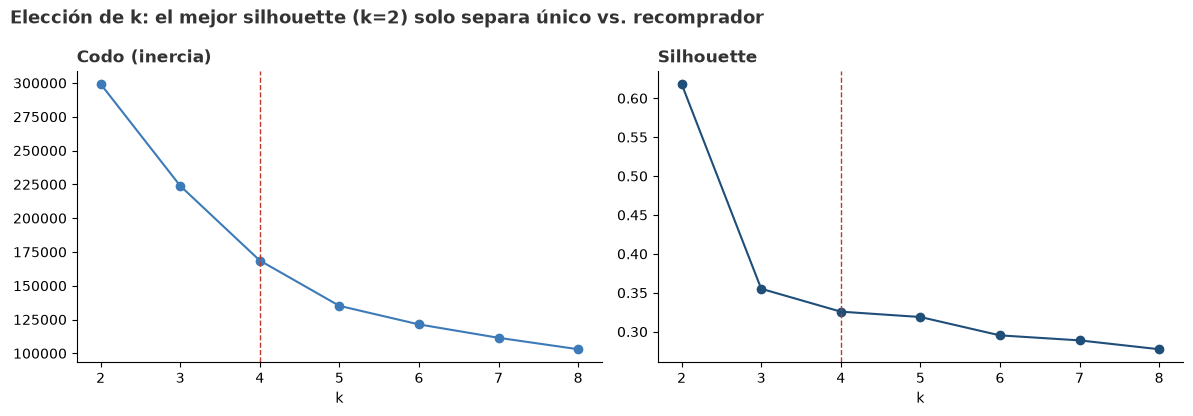

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

ax1.plot(evaluacion["k"], evaluacion["inercia"], marker="o", color=COLOR_BARRA)
ax1.set_title("Codo (inercia)", fontsize=12, fontweight="bold", loc="left", color=COLOR_TEXTO)
ax1.set_xlabel("k")
ax1.axvline(4, color="#c0392b", linestyle="--", linewidth=1)

ax2.plot(evaluacion["k"], evaluacion["silhouette"], marker="o", color=COLOR_DESTACADO)
ax2.set_title("Silhouette", fontsize=12, fontweight="bold", loc="left", color=COLOR_TEXTO)
ax2.set_xlabel("k")
ax2.axvline(4, color="#c0392b", linestyle="--", linewidth=1)

for ax in (ax1, ax2):
    for lado in ("top", "right"):
        ax.spines[lado].set_visible(False)

fig.suptitle("Elección de k: el mejor silhouette (k=2) solo separa único vs. recomprador", fontsize=13, fontweight="bold", x=0.01, ha="left", color=COLOR_TEXTO)
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / "2_1_codo_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# k=2 tiene el mejor silhouette, pero comprobamos qué separa realmente
clientes_k2 = segmentar_kmeans(clientes, matriz_escalada, k=2)
perfil_segmentos(clientes_k2, "cluster")[["cluster", "clientes", "pct_clientes", "pct_ingresos", "frecuencia_media", "recencia_mediana", "gasto_mediano", "score_promedio"]]

,cluster,clientes,pct_clientes,pct_ingresos,frecuencia_media,recencia_mediana,gasto_mediano,score_promedio
0,0,92103,96.96,94.34,1.00,220.0,105.65,4.11
1,1,2887,3.04,5.66,2.11,201.0,225.51,4.16


In [15]:
# k=4: el codo, y el único que produce grupos con lectura de negocio
K_ELEGIDO = 4
clientes = segmentar_kmeans(clientes, matriz_escalada, k=K_ELEGIDO)
perfil_kmeans = perfil_segmentos(clientes, "cluster")
perfil_kmeans

,cluster,clientes,pct_clientes,ingresos,pct_ingresos,recencia_mediana,frecuencia_media,gasto_mediano,ticket_mediano,score_promedio,pct_mala_experiencia,top_categorias
0,0,16358,17.22,3110568.37,19.76,219.0,1.00,121.59,121.59,1.62,77.88,"Cama, mesa y baño, Belleza y salud, Informátic..."
1,1,43133,45.41,6594824.94,41.90,121.0,1.00,102.64,102.64,4.67,0.01,"Belleza y salud, Cama, mesa y baño, Deporte y ..."
2,2,32612,34.33,5143519.50,32.68,383.0,1.00,102.36,102.36,4.63,0.08,"Cama, mesa y baño, Deporte y ocio, Belleza y s..."
3,3,2887,3.04,890201.20,5.66,201.0,2.11,225.51,109.83,4.16,20.44,"Cama, mesa y baño, Deporte y ocio, Muebles y d..."


**Lectura de los 4 clusters:** K-Means no encuentra valor, encuentra **satisfacción y antigüedad**.

- Un cluster de **clientes insatisfechos** (≈78% con mala experiencia, score 1,6): 17% de la base y ~20% de los ingresos.
- Uno de **recientes satisfechos**, uno de **antiguos satisfechos** (recencia mediana > 380 días) y uno de **recompradores** (el 3% que compra más de una vez).
- Ningún cluster de alto gasto: el dinero no es la dimensión que más separa a estos clientes.

### Paso 6 – Comparación A vs B y elección

El cruce muestra dónde coinciden y dónde no los dos enfoques.

In [16]:
cruce = pd.crosstab(clientes["segmento"], clientes["cluster"], margins=True, margins_name="Total")
cruce

cluster,0,1,2,3,Total
segmento,,,,,
Fieles,0,0,0,1060,1060
VIP / Alto valor,2057,3574,2980,530,9141
Esporádicos recientes,4368,27780,0,100,32248
En riesgo de abandono,5911,11779,4480,557,22727
Perdidos / Inactivos,4022,0,25152,640,29814
Total,16358,43133,32612,2887,94990


**Se elige el enfoque A (reglas RFM) para marketing**, por tres razones:

1. **Accionabilidad:** las reglas separan lo que marketing puede mover (recencia y valor) y ponen precio a cada grupo: el 9,6% de alto valor vale el 36,9% de los ingresos. K-Means reparte el gasto casi por igual entre sus clusters (20–42%), así que no sirve para priorizar presupuesto.
2. **Interpretabilidad y estabilidad:** un umbral de 171 días se explica en una frase y se recalcula cada mes; un centroide en 4 dimensiones estandarizadas no, y cambia con cada re-entrenamiento.
3. **Trazabilidad:** cada cliente sabe por qué está donde está, requisito para un equipo que va a mandar campañas y para el agente del 3.2.

**Pero K-Means no se descarta:** aporta un hallazgo que las reglas no buscaban. Al dejar que los datos decidan, la variable que más separa a la base es la **insatisfacción**, no el dinero. Ese cluster insatisfecho (17% de los clientes, 20% de los ingresos) es exactamente la población que debe atender el equipo de PQR, y es la validación cruzada de que el dolor del 1.2 no es un detalle operativo: es un eje estructural de la base de clientes.

### Paso 7 – Perfil por segmento y acción de marketing

In [17]:
perfil_final = perfil_reglas.copy()
perfil_final["accion_marketing"] = perfil_final["segmento"].map(ACCIONES_MARKETING)
ruta_tabla = guardar_tabla(perfil_final, "2_1_perfil_segmentos.csv")
print(ruta_tabla)

for fila in perfil_final.itertuples():
    print(f"\n{fila.segmento}: {fila.clientes:,} clientes ({fila.pct_clientes}%) · {formato_moneda(fila.ingresos)} ({fila.pct_ingresos}% de los ingresos)")
    print(f"  recencia mediana {fila.recencia_mediana:.0f} d · gasto mediano {formato_moneda(fila.gasto_mediano)} · score {fila.score_promedio:.2f} · mala experiencia {fila.pct_mala_experiencia:.1f}%")
    print(f"  Acción: {fila.accion_marketing}")

C:\Users\user\Downloads\prueba-tecnica-proteccion-ds-ia\reports\tables\2_1_perfil_segmentos.csv

Fieles: 1,060 clientes (1.12%) · R$ 345.946 (2.2% de los ingresos)
  recencia mediana 84 d · gasto mediano R$ 240 · score 4.30 · mala experiencia 18.9%
  Acción: Programa de fidelización y cross-sell: son los únicos con hábito de recompra.

VIP / Alto valor: 9,141 clientes (9.62%) · R$ 5.809.865 (36.91% de los ingresos)
  recencia mediana 225 d · gasto mediano R$ 472 · score 3.96 · mala experiencia 18.8%
  Acción: Atención preferente y recompra asistida; reactivar al VIP dormido antes que captar uno nuevo.

Esporádicos recientes: 32,248 clientes (33.95%) · R$ 3.659.645 (23.25% de los ingresos)
  recencia mediana 88 d · gasto mediano R$ 98 · score 4.21 · mala experiencia 11.8%
  Acción: Segunda compra en caliente: cupón con vencimiento en las semanas siguientes.

En riesgo de abandono: 22,727 clientes (23.93%) · R$ 2.577.722 (16.38% de los ingresos)
  recencia mediana 226 d · gasto mediano R

### Paso 8 – Variable `HISTORIAL_COMPRAS` para el agente de IA (punto 3.2)

El agente no puede recibir una tabla: recibe una frase con los hechos que cambian el tono de la conversación.

In [18]:
clientes["historial_compras"] = construir_historial_compras(clientes)

for segmento in ["Fieles", "VIP / Alto valor", "En riesgo de abandono"]:
    ejemplo = clientes[clientes["segmento"] == segmento].iloc[0]
    print(f"[{segmento}]\n  {ejemplo['historial_compras']}\n")

[Fieles]
  2 pedidos | gasto total R$148 | ticket prom. R$74 | categoría favorita: Herramientas de jardín | última compra hace 95 días | score prom. 3.0 | mala experiencia: sí | motivo: entrega / retraso | segmento: Fieles

[VIP / Alto valor]
  1 pedido | gasto total R$419 | ticket prom. R$419 | categoría favorita: Deporte y ocio | última compra hace 182 días | score prom. 1.0 | mala experiencia: sí | motivo: reembolso / cancelación | segmento: VIP / Alto valor

[En riesgo de abandono]
  1 pedido | gasto total R$29 | ticket prom. R$29 | categoría favorita: Cama, mesa y baño | última compra hace 260 días | score prom. 5.0 | mala experiencia: no | segmento: En riesgo de abandono



### Paso 9 – Validaciones y guardado

In [19]:
gasto_base = base["monto"].sum()
gasto_segmentos = clientes.groupby("segmento", observed=True)["gasto_total"].sum().sum()

validaciones = [
    (
        "Clientes = customer_unique_id únicos con pedidos válidos",
        len(clientes) == base["customer_unique_id"].nunique(),
        f"{len(clientes):,} = {base['customer_unique_id'].nunique():,}",
    ),
    (
        "Suma de clientes por segmento = total (sin duplicados ni sin segmento)",
        clientes.groupby("segmento", observed=True).size().sum() == len(clientes) and clientes["segmento"].isna().sum() == 0,
        f"{clientes.groupby('segmento', observed=True).size().sum():,} de {len(clientes):,}",
    ),
    (
        "Gasto por segmento = gasto de los pedidos válidos",
        abs(gasto_segmentos - gasto_base) < 1,
        f"{formato_moneda(gasto_segmentos)} vs {formato_moneda(gasto_base)}",
    ),
    (
        "Recencia sin negativos",
        (clientes["recencia"] < 0).sum() == 0,
        f"mínimo {clientes['recencia'].min()} días, máximo {clientes['recencia'].max()} días",
    ),
    (
        "Frecuencia = pedidos válidos en la ventana",
        clientes["frecuencia"].sum() == base["order_id"].nunique(),
        f"{clientes['frecuencia'].sum():,} = {base['order_id'].nunique():,} pedidos",
    ),
    (
        "Todos los clientes tienen historial_compras",
        clientes["historial_compras"].notna().all(),
        f"{clientes['historial_compras'].notna().sum():,} de {len(clientes):,}",
    ),
]
imprimir_checklist(validaciones)

CHECKLIST DE VALIDACIÓN
----------------------------------------------------------------------
✅ Clientes = customer_unique_id únicos con pedidos válidos: 94,990 = 94,990
✅ Suma de clientes por segmento = total (sin duplicados ni sin segmento): 94,990 de 94,990
✅ Gasto por segmento = gasto de los pedidos válidos: R$ 15.739.114 vs R$ 15.739.114
✅ Recencia sin negativos: mínimo 0 días, máximo 724 días
✅ Frecuencia = pedidos válidos en la ventana: 98,206 = 98,206 pedidos
✅ Todos los clientes tienen historial_compras: 94,990 de 94,990
----------------------------------------------------------------------
TODAS LAS VALIDACIONES PASARON


True

In [20]:
columnas_salida = [
    "customer_unique_id", "segmento", "subsegmento", "alto_valor", "cluster",
    "recencia", "frecuencia", "dias_compra", "gasto_total", "ticket_promedio",
    "categorias_distintas", "categoria_favorita", "score_promedio",
    "tuvo_mala_experiencia", "motivo_principal", "max_retraso_dias",
    "metodo_pago", "cuotas_promedio", "estado", "ciudad",
    "primera_compra", "ultima_compra", "antiguedad", "historial_compras",
]
salida = clientes[columnas_salida].copy()
salida["segmento"] = salida["segmento"].astype(str)
ruta = RUTA_PROCESSED / "clientes_segmentados.parquet"
salida.to_parquet(ruta, index=False)
print(f"Guardado: {ruta} · {salida.shape}")

Guardado: C:\Users\user\Downloads\prueba-tecnica-proteccion-ds-ia\data\processed\clientes_segmentados.parquet · (94990, 24)


### Conclusión: qué aporta el RFM y qué aporta el K-Means

**Con reglas RFM (lo que se lleva marketing):**
- La base **no tiene clientes fieles en volumen relevante**: solo 1.060 personas (1,1%) compraron en más de un día y siguen activas. Vender fidelidad como estrategia central en este negocio sería vender algo que no existe todavía; el objetivo realista es **la segunda compra**.
- El valor está concentrado, no repartido: **9.141 clientes (9,6%) generan el 36,9% de los ingresos** con una sola compra promedio. Ahí está el retorno de cualquier peso invertido en retención.
- El **55% de la base ya está fuera del ciclo** de recompra (23,9% en riesgo + 31,4% perdidos) y aporta el 37,6% de los ingresos históricos. Es una base que se apaga, no que se acumula.
- Los umbrales salen de los datos y se pueden recalcular: 171 días para riesgo, 281 para abandono, R$ 319 para alto valor.

**Con K-Means (lo que valida y lo que descubre):**
- Confirma el diagnóstico estructural: con el mejor silhouette (k=2) el algoritmo solo logra separar **comprador único vs. recomprador**, la prueba matemática de que la Frecuencia es casi constante en esta base.
- Y aporta lo que las reglas no buscaban: con k=4 la dimensión que más separa a los clientes **no es el dinero, es la satisfacción**. Aparece un cluster de 16.358 clientes (17,2% de la base, 19,8% de los ingresos) con score promedio 1,6 y 77,9% de malas experiencias.

**Cómo se usan juntos en la sustentación:** las reglas responden *"¿a quién le hablo y con qué presupuesto?"*; el K-Means responde *"¿qué separa de verdad a mis clientes?"* y su respuesta es el dolor del punto 1.2. Un cliente en riesgo con mala experiencia no necesita un cupón, necesita que le resuelvan el PQR primero: esa es la regla de negocio que hereda el agente del punto 3.2.